In [124]:
%pip install scikit-learn # Install scikit-learn
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [125]:
import os
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.distributions import Normal
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve

In [126]:
np.random.seed(0)

In [127]:
def fetch_mnist():
  trans_mnist = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
  dataset_train = datasets.MNIST('./data/mnist/', train=True, download=True, transform=trans_mnist)
  dataset_test = datasets.MNIST('./data/mnist/', train=False, download=True, transform=trans_mnist)
  return dataset_train, dataset_test

In [128]:
def create_encoder(input_dim, latent_dim):
    encoder = nn.Sequential(
        nn.Linear(input_dim, 128),
        nn.ReLU(inplace=False),
        nn.Linear(128, 64),
        nn.ReLU(inplace=False)
    )
    mean = nn.Linear(64, latent_dim)
    logvar = nn.Linear(64, latent_dim)
    return encoder, mean, logvar

def create_decoder(latent_dim, output_dim):
    return nn.Sequential(
        nn.Linear(latent_dim, 64),
        nn.ReLU(inplace=False),
        nn.Linear(64, 128),
        nn.ReLU(inplace=False),
        nn.Linear(128, output_dim)
    )

# Reparameterization trick
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std


In [129]:
def create_generator(noise_dim, output_dim):
    return nn.Sequential(
        nn.Linear(noise_dim, 128),
        nn.ReLU(),
        nn.Linear(128, 256),
        nn.ReLU(),
        nn.Linear(256, output_dim),
        nn.Tanh()
    )

def create_discriminator(input_dim):
    return nn.Sequential(
        nn.Linear(input_dim, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 1),
        nn.Sigmoid()
    )

In [130]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(config['num_channels'], 10, kernel_size=5),
            nn.BatchNorm2d(10),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(10, 20, kernel_size=5),
            nn.BatchNorm2d(20),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Flatten layer output to match 784 (MNIST flattened)
        self.fc = nn.Linear(320, 784)  # Adjust output to match input_dim=784 in encoder

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = x.view(x.size(0), -1)  # Flatten
        return self.fc(x)

In [131]:
def save_checkpoint(epoch, models, optimizers, ensemble_weights, config, filename):

    if not os.path.exists(os.path.dirname(filename)):
        os.makedirs(os.path.dirname(filename), exist_ok=True)

    # Create state dicts for all models and optimizers
    models_state = {name: model.state_dict() for name, model in models.items()}
    optimizers_state = {name: opt.state_dict() for name, opt in optimizers.items()}

    checkpoint = {
        'epoch': epoch,
        'models': models_state,
        'optimizers': optimizers_state,
        'ensemble_weights': ensemble_weights,
        'config': config
    }
    torch.save(checkpoint, filename)


def load_checkpoint(filename, models, optimizers):

    checkpoint = torch.load(filename, map_location=torch.device('cpu') if not torch.cuda.is_available() else 'gpu', weights_only=True)

    for key, model in models.items():
        model.load_state_dict(checkpoint['models'][key])

    for key, optimizer in optimizers.items():
        optimizer.load_state_dict(checkpoint['optimizers'][key])

    epoch = checkpoint['epoch']
    ensemble_weights = checkpoint['ensemble_weights']
    config = checkpoint['config']

    print(f"Checkpoint loaded successfully from epoch {epoch}")
    return epoch, models, optimizers, ensemble_weights, config


In [132]:
def compute_feature_vectors(model, data, device):
    model.eval()
    with torch.no_grad():
        if data.dim() == 3:
            data = data.unsqueeze(1)
        features = model(data.to(device))
    return features

def compute_outputs(features, noise, models, ensemble_weights):
    # VAE outputs
    encoded = models['encoder'](features)
    mu = models['mean'](encoded)
    logvar = models['logvar'](encoded)
    z = reparameterize(mu, logvar)
    vae_output = models['decoder'](z)

    #GAN outputs
    gan_output = models['generator'](noise)

    # Ensemble output with softmax weights
    weights = nn.functional.softmax(ensemble_weights, dim=0)

    # Create ensemble output without detaching weights
    e_output = weights[0] * vae_output + weights[1] * gan_output

    return {
        'vae_output': vae_output,
        'gan_output': gan_output,
        'ensemble_output': e_output,
        'mu': mu,
        'logvar': logvar,
        'weights': weights
    }

In [133]:
def training_simulation(config, train_loader, checkpoint_filename):
    def vae_loss(real_data, vae_output, mu, logvar):
        recon = nn.functional.mse_loss(vae_output, real_data, reduction='sum')
        kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        return (recon + kl_div) / real_data.size(0)

    def compute_disc_loss(real_data, fake_data):
        real_preds = models['discriminator'](real_data)
        fake_data_pred = models['discriminator'](fake_data)
        real_loss = torch.mean(torch.log(real_preds + 1e-8))
        fake_loss = torch.mean(torch.log(1 - fake_data_pred + 1e-8))
        return -(real_loss + fake_loss)

    def compute_gen_loss(fake_data):
        fake_preds = models['discriminator'](fake_data)
        return -torch.mean(torch.log(fake_preds + 1e-8))

    device = torch.device(config['device'])
    input_dim = output_dim = config['input_dim']

    # Initialize models
    feature_extractor = CNNFeatureExtractor(config).to(device)
    encoder_base, mean_layer, logvar_layer = create_encoder(input_dim, config['latent_dim'])
    decoder_model = create_decoder(config['latent_dim'], output_dim)
    gen_model = create_generator(config['noise_dim'], output_dim)
    disc_model = create_discriminator(input_dim)

    # Move models to device
    models = {
        'feature_extractor': feature_extractor,
        'encoder': encoder_base.to(device),
        'mean': mean_layer.to(device),
        'logvar': logvar_layer.to(device),
        'decoder': decoder_model.to(device),
        'generator': gen_model.to(device),
        'discriminator': disc_model.to(device)
    }

    ensemble_weights = nn.Parameter(torch.tensor([0.5, 0.5], device=device))

    optimizers = {
        'feature_extractor': optim.Adam(models['feature_extractor'].parameters(), lr=config['lr']),
        'vae': optim.Adam(
            list(models['encoder'].parameters()) +
            list(models['decoder'].parameters()) +
            list(models['mean'].parameters()) +
            list(models['logvar'].parameters()),
            lr=config['lr']
        ),
        'gen': optim.Adam(models['generator'].parameters(), lr=config['lr']),
        'disc': optim.Adam(models['discriminator'].parameters(), lr=config['lr']),
        'weights': optim.Adam([ensemble_weights], lr=config['lr'])
    }

    schedulers = {
        key: torch.optim.lr_scheduler.StepLR(opt, step_size=config['lr'], gamma=config['gamma'])
        for key,opt in optimizers.items()
    }

    if checkpoint_filename and os.path.exists(checkpoint_filename):
        start_epoch , models, optimizers, ensemble_weights, config = load_checkpoint(checkpoint_filename, models, optimizers)
    else:
        start_epoch = 1

    # Training loop
    for epoch in range(start_epoch, config['num_epochs']):

        for batch_idx, (data, _) in tqdm(enumerate(train_loader), total=len(train_loader), desc=f'Epoch [{epoch }/{config["num_epochs"]}]'):

            # Compute feature vectors and noise
            features = compute_feature_vectors(models['feature_extractor'], data, device)
            noise = torch.randn(features.size(0), config['noise_dim']).to(device)

            # Get all outputs
            outputs = compute_outputs(features, noise, models, ensemble_weights)

            # Feature extractor update
            optimizers['feature_extractor'].zero_grad()
            feature_loss = nn.functional.mse_loss(outputs['ensemble_output'], features)
            feature_loss.backward(retain_graph=True)
            optimizers['feature_extractor'].step()

            # VAE update
            optimizers['vae'].zero_grad()
            vae_loss_val = vae_loss(features, outputs['vae_output'], outputs['mu'], outputs['logvar'])
            vae_loss_val.backward(retain_graph=True)
            optimizers['vae'].step()

            # Discriminator update
            optimizers['disc'].zero_grad()
            d_loss = compute_disc_loss(features, outputs['gan_output'])
            d_loss.backward(retain_graph=True)
            optimizers['disc'].step()

            # Generator update
            optimizers['gen'].zero_grad()
            g_loss = compute_gen_loss(outputs['gan_output'])
            g_loss.backward(retain_graph=True)
            optimizers['gen'].step()

            # Ensemble weights update
            optimizers['weights'].zero_grad()

            # Recompute outputs for ensemble update
            fresh_outputs = compute_outputs(features, noise, models, ensemble_weights)
            ensemble_reconstr_loss = nn.functional.mse_loss(fresh_outputs['ensemble_output'], features)
            weight_reg = torch.abs(fresh_outputs['weights'].sum() - 1.0)
            e_loss = ensemble_reconstr_loss + weight_reg

            e_loss.backward()
            optimizers['weights'].step()

        # Step the schedulers after each epoch
        for scheduler in schedulers.values():
            scheduler.step()
            
        save_checkpoint(epoch+1, models, optimizers, ensemble_weights, config, checkpoint_filename)

    return models, ensemble_weights

In [134]:
def compute_anomaly_score(features, models, ensemble_weights, config, device):
    noise = torch.randn(features.size(0), config['noise_dim']).to(device)
    outputs = compute_outputs(features, noise, models, ensemble_weights)

    # Multi-Metric Anomaly Scoring
    reconstruction_error = torch.mean((features - outputs['ensemble_output'])**2, dim=1)

    # KL Divergence for distribution shift
    kl_divergence = -0.5 * torch.sum(1 + outputs['logvar'] - outputs['mu'].pow(2) - outputs['logvar'].exp(), dim=1)

    # Ensemble Variance
    ensemble_variance = torch.var(torch.stack([
        outputs['vae_output'], 
        outputs['gan_output']
    ]), dim=0).mean(dim=1)


    # Discriminator Confidence (lower score means more suspicious)
    discriminator_confidence = 1 - models['discriminator'](features).squeeze()

    # Weighted Composite Score
    weights = {
        'reconstruction': 0.4,
        'kl_divergence': 0.2,
        'ensemble_variance': 0.2,
        'discriminator_confidence': 0.2
    }

    composite_score = (
        weights['reconstruction'] * reconstruction_error + weights['kl_divergence'] * kl_divergence +
        weights['ensemble_variance'] * ensemble_variance + weights['discriminator_confidence'] * discriminator_confidence
    )

 # Normalize scores
    scores = (composite_score - composite_score.min()) / (composite_score.max() - composite_score.min() + 1e-10)

    return scores, noise, outputs

def evaluate_poison(models, clean_loader, poison_type="label_flip", poison_ratio=0.3, device='cpu'):

    # Lists to store results
    clean_scores = []
    poison_scores = []

    for model in models.values():
        model.eval()

    with torch.no_grad():
        for batch_idx, (data, _) in enumerate(clean_loader):
          
          clean_features = compute_feature_vectors(models['feature_extractor'], data, device)
          clean_batch_scores, _, _ = compute_anomaly_score(clean_features, models, ensemble_weights, config, device)
          clean_scores.extend(clean_batch_scores.cpu().numpy())

          
          poisoned_data = simulate_poison_attack(data, type=poison_type, poison_ratio=poison_ratio)
          poison_features = compute_feature_vectors(models['feature_extractor'], poisoned_data, device)
          poison_batch_scores, _, _ = compute_anomaly_score(
              poison_features, models, ensemble_weights, config, device
          )
          poison_scores.extend(poison_batch_scores.cpu().numpy())

    # Convert to numpy arrays
    clean_scores = np.array(clean_scores)
    poison_scores = np.array(poison_scores)

    threshold = np.percentile(clean_scores, 95)

    tp = np.sum(poison_scores > threshold)
    fp = np.sum(clean_scores > threshold)
    tn = np.sum(clean_scores <= threshold)
    fn = np.sum(poison_scores <= threshold)

    precision = tp / (tp + fp + 1e-10)
    recall = tp / (tp + fn + 1e-10)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-10)

    # Visualize results
    # plt.figure(figsize=(10, 6))
    # plt.hist(clean_scores, bins=50, alpha=0.5, label='Clean Data', density=True)
    # plt.hist(poison_scores, bins=50, alpha=0.5, label='Poisoned Data', density=True)
    # plt.axvline(x=threshold, color='r', linestyle='--', label='Detection Threshold')
    # plt.xlabel('Anomaly Score')
    # plt.ylabel('Density')
    # plt.title(f'Distribution of Anomaly Scores for Clean vs Poisoned ({poison_type}) Data')
    # plt.legend()
    # plt.grid(True)
    # plt.show()

    print(f"\nPoisoning Detection Results ({poison_type}):")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'threshold': threshold,
        'clean_scores': clean_scores,
        'poison_scores': poison_scores
    }


In [135]:
def compare_poison_types(model, clean_loader, device):
    poison_types = ['label_flip', 'gradient_ascent', 'model_replacement']
    poison_ratios = [0.1, 0.3, 0.5]

    results = {}

    for poison_type in poison_types:
        type_results = []
        for poison_ratio in poison_ratios:
            print(f"Evaluating {poison_type} with ratio {poison_ratio}")
            metrics = evaluate_poison(model, clean_loader, 
                                   poison_type=poison_type, 
                                   poison_ratio=poison_ratio, 
                                   device=device)
            type_results.append(metrics)
        results[poison_type] = type_results

    # Visualize comparison
    plt.figure(figsize=(12, 6))
    x = np.arange(len(poison_ratios))
    width = 0.25

    for i, poison_type in enumerate(poison_types):
        f1_scores = [r['f1'] for r in results[poison_type]]
        plt.bar(x + i*width, f1_scores, width, label=poison_type)

    plt.xlabel('Poisoning Ratio')
    plt.ylabel('F1 Score')
    plt.title('Poisoning Detection Performance Comparison')
    plt.xticks(x + width, [f'{r*100}%' for r in poison_ratios])
    plt.legend()
    plt.grid(True)
    plt.show()

    return results

In [136]:
def simulate_poison_attack(data, type="label_flip", poison_ratio = 0.3):
  poisoned_data = data.clone()
  poison_samples = int(len(data) * poison_ratio)
  poison_mask = torch.zeros(len(data), dtype=torch.bool)

  indices = torch.randperm(len(data))[:poison_samples]
  poison_mask[indices] = True

  if type == 'label_flip':
    poisoned_data[indices] = -poisoned_data[indices]
  elif type == 'gradient_ascent':
    poisoned_data[indices] = poisoned_data[indices] * -2.0
  elif type == 'model_replacement':
    poisoned_data[indices] = torch.randn_like(poisoned_data[indices]) * 5.0

  return poisoned_data

In [ ]:
checkpoint_filename = '/Users/loji/Documents/FYP/fed-ensemble/fed_ensemble/checkpoint.pt'
train_dataset, test_dataset = fetch_mnist()
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)


config = {
    'input_dim': train_dataset.data.shape[1] * train_dataset.data.shape[2],
    'latent_dim': 20,
    'noise_dim': 100,
    'lr': 0.0001,
    'gamma': 0.9,
    'num_channels': 1,
    'num_classes': len(train_dataset.classes),
    'img_size': 28,
    'num_epochs': 15,
    'batch_size': 64,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
    }

models, ensemble_weights = training_simulation(config, train_dataset, checkpoint_filename)

{'feature_extractor': <torch.optim.lr_scheduler.StepLR object at 0x314a309a0>, 'vae': <torch.optim.lr_scheduler.StepLR object at 0x314a30970>, 'gen': <torch.optim.lr_scheduler.StepLR object at 0x314a30f40>, 'disc': <torch.optim.lr_scheduler.StepLR object at 0x314a30b80>, 'weights': <torch.optim.lr_scheduler.StepLR object at 0x314a303d0>}
Checkpoint loaded successfully from epoch 15


Evaluating poisoning detection capabilities...

Poisoning Detection Results (label_flip):
Precision: 0.5229
Recall: 0.0548
F1 Score: 0.0992
Evaluating label_flip with ratio 0.1

Poisoning Detection Results (label_flip):
Precision: 0.5098
Recall: 0.0520
F1 Score: 0.0944
Evaluating label_flip with ratio 0.3

Poisoning Detection Results (label_flip):
Precision: 0.5188
Recall: 0.0539
F1 Score: 0.0977
Evaluating label_flip with ratio 0.5

Poisoning Detection Results (label_flip):
Precision: 0.5274
Recall: 0.0558
F1 Score: 0.1009
Evaluating gradient_ascent with ratio 0.1

Poisoning Detection Results (gradient_ascent):
Precision: 0.4505
Recall: 0.0410
F1 Score: 0.0752
Evaluating gradient_ascent with ratio 0.3

Poisoning Detection Results (gradient_ascent):
Precision: 0.5243
Recall: 0.0551
F1 Score: 0.0997
Evaluating gradient_ascent with ratio 0.5

Poisoning Detection Results (gradient_ascent):
Precision: 0.5745
Recall: 0.0675
F1 Score: 0.1208
Evaluating model_replacement with ratio 0.1

Poiso

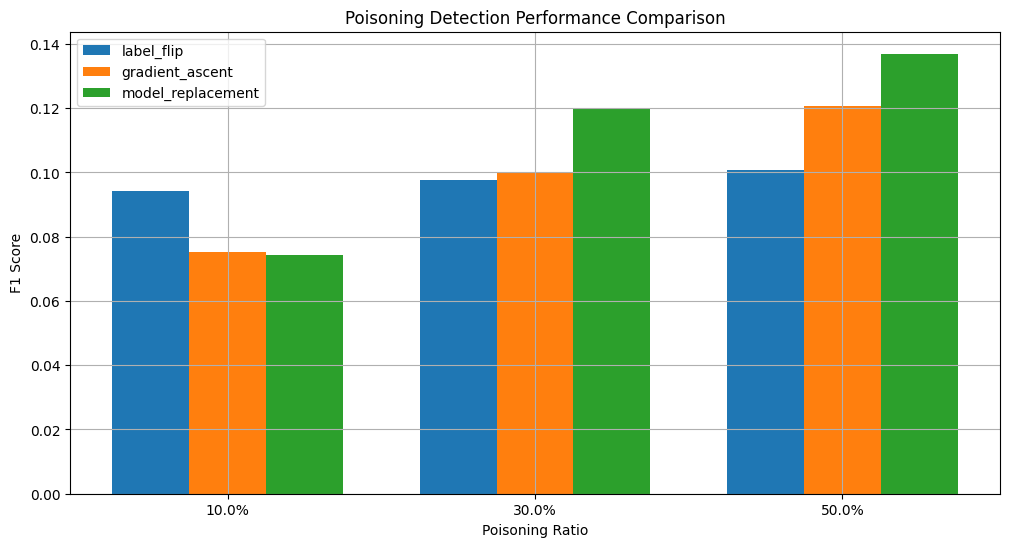

In [138]:
# After training the models and ensemble_weights
print("Evaluating poisoning detection capabilities...")

# Test individual poison type
results = evaluate_poison(
    models, test_loader,
    poison_type="label_flip",
    poison_ratio=0.3,
    device=config['device'] 
)

# Compare different poisoning types and ratios
comparison_results = compare_poison_types(
    models, test_loader,
    device=config['device']
)